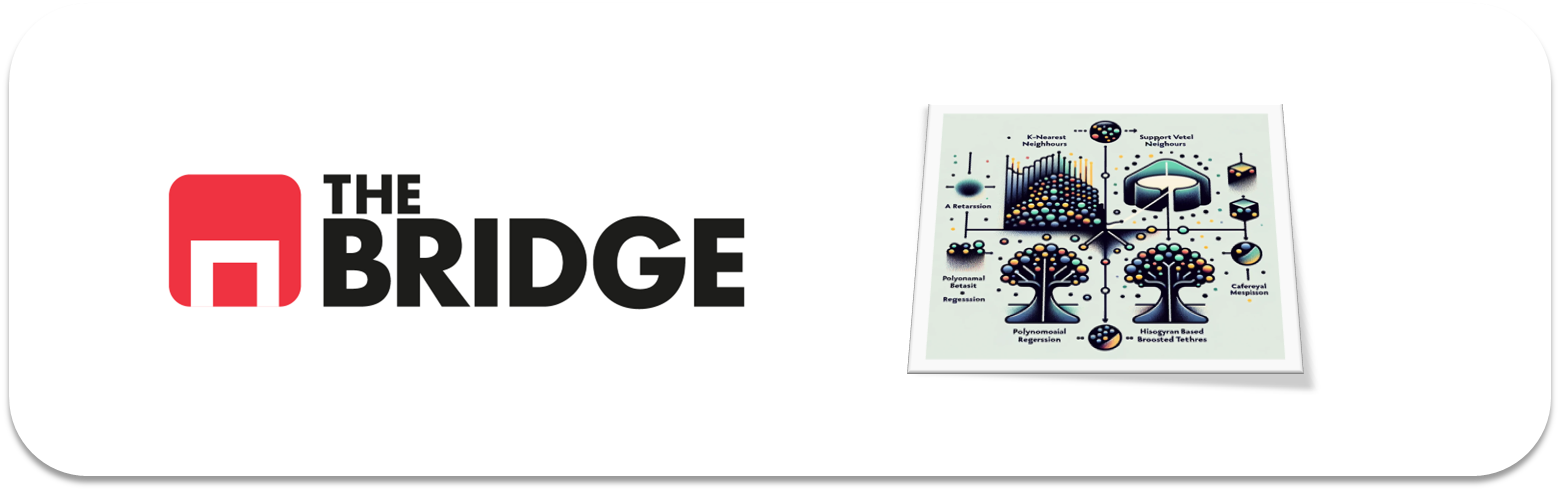

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from bootcampviztools import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
df_vinos=pd.read_csv("./data/wines_dataset.csv", sep="|")
display(df_vinos)
df_vinos.info()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,7.7,0.39,0.34,10.00,0.056,35.0,178.0,0.99740,3.26,0.60,10.2,5,white
6493,8.2,0.73,0.21,1.70,0.074,5.0,13.0,0.99680,3.20,0.52,9.5,5,red
6494,7.4,0.31,0.48,14.20,0.042,62.0,204.0,0.99830,3.06,0.59,9.4,5,white
6495,8.3,0.65,0.10,2.90,0.089,17.0,40.0,0.99803,3.29,0.55,9.5,5,red


<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


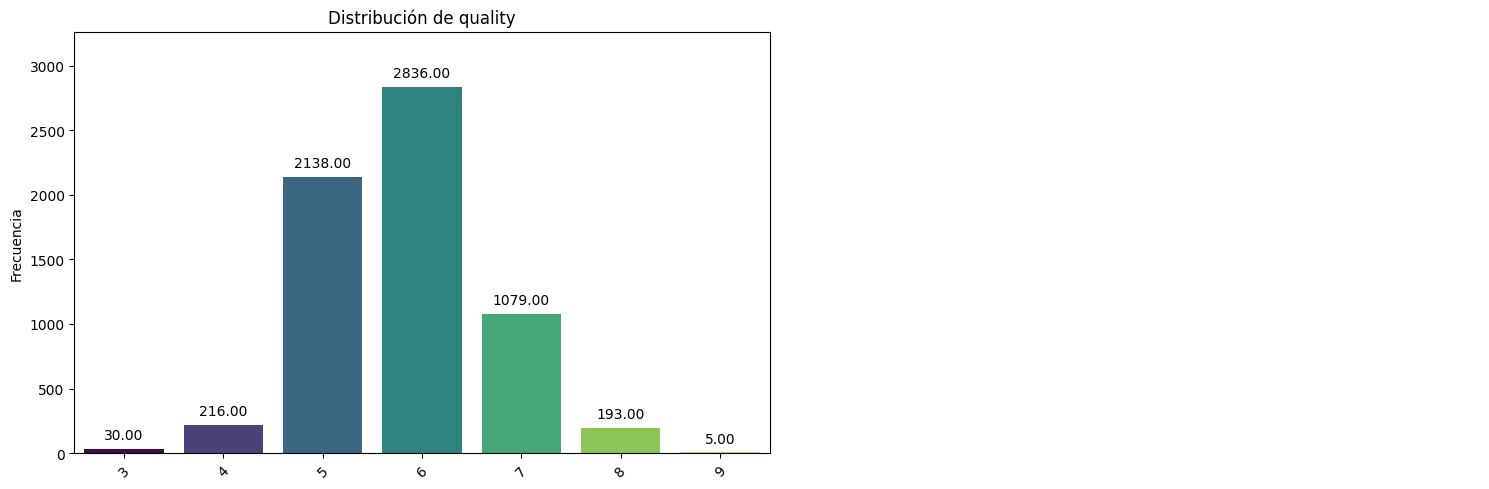

In [11]:
pinta_distribucion_categoricas(df_vinos,["quality"],relativa=False, mostrar_valores=True)

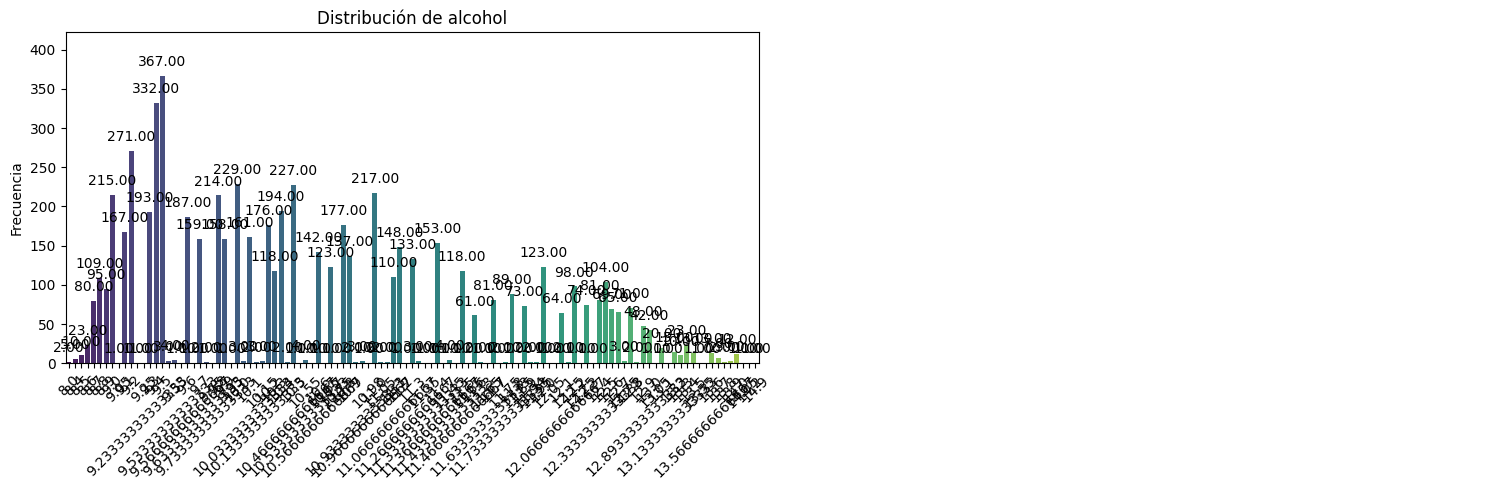

In [12]:
pinta_distribucion_categoricas(df_vinos,["alcohol"],relativa=False, mostrar_valores=True)

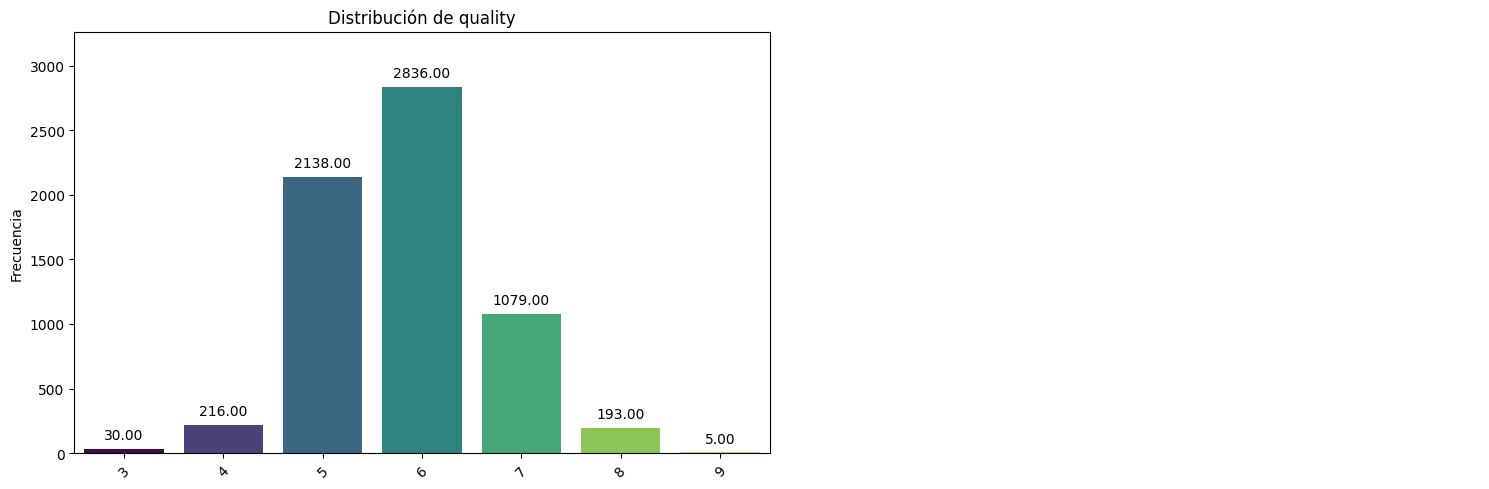

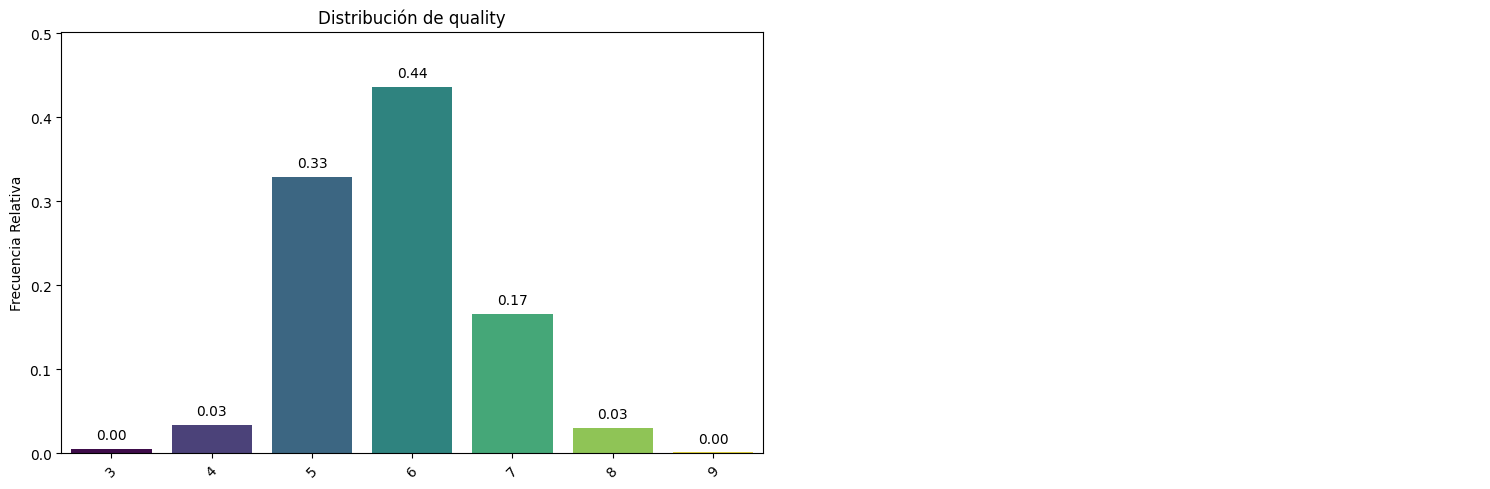

In [18]:

df=df_vinos.copy()
pinta_distribucion_categoricas(df,["quality"],relativa=False, mostrar_valores=True)

pinta_distribucion_categoricas(df,["quality"],relativa=True, mostrar_valores=True)


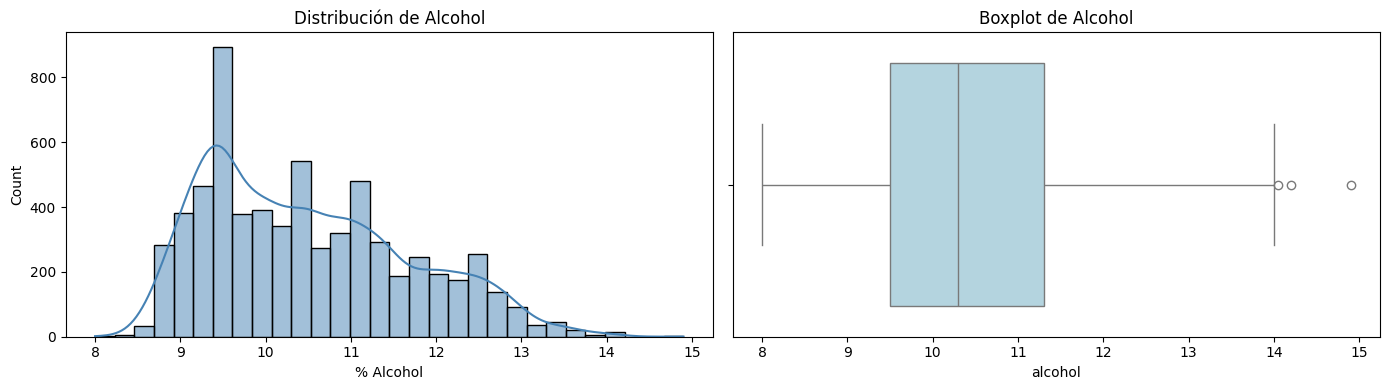

count    6497.000
mean       10.492
std         1.193
min         8.000
25%         9.500
50%        10.300
75%        11.300
max        14.900
Name: alcohol, dtype: float64


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['alcohol'], kde=True, bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de Alcohol')
axes[0].set_xlabel('% Alcohol')

sns.boxplot(x=df['alcohol'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot de Alcohol')

plt.tight_layout()
plt.show()

print(df['alcohol'].describe().round(3))

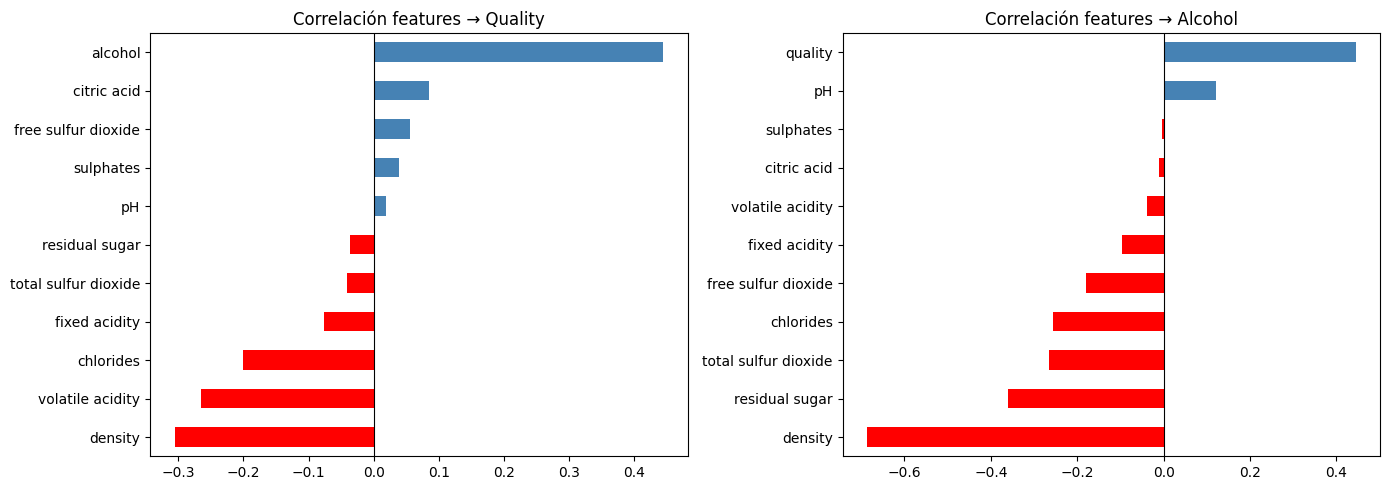

In [20]:
# Correlaciones con quality y alcohol
corr_quality = df.corr(numeric_only=True)['quality'].drop('quality').sort_values()
corr_alcohol = df.corr(numeric_only=True)['alcohol'].drop('alcohol').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr_quality.plot(kind='barh', ax=axes[0], color=['red' if x < 0 else 'steelblue' for x in corr_quality])
axes[0].set_title('Correlación features → Quality')
axes[0].axvline(0, color='black', linewidth=0.8)

corr_alcohol.plot(kind='barh', ax=axes[1], color=['red' if x < 0 else 'steelblue' for x in corr_alcohol])
axes[1].set_title('Correlación features → Alcohol')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [23]:
X=df.drop(columns=["quality"])
y=df["quality"]
target1="quality"
# Codificar variable categórica 'class'
X = pd.get_dummies(X, columns=['class'], drop_first=True)

X_train,X_test,y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

#Escalado
scaler=StandardScaler()
X_train_sc=scaler.fit_transform(X_train)
X_test_sc=scaler.transform(X_test)


print(f"Train: {X_train_sc.shape} | Test: {X_test_sc.shape}")
print(f"\nDistribución de clases en train:")
print(y_train.value_counts().sort_index())


Train: (5197, 12) | Test: (1300, 12)

Distribución de clases en train:
quality
3      24
4     173
5    1710
6    2269
7     863
8     154
9       4
Name: count, dtype: int64


In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

resultados_knn = {}

for k in [3, 5, 7, 11, 15]:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(
        knn, X_train_sc, y_train,
        cv=5, scoring='recall_macro', n_jobs=-1
    )
    resultados_knn[k] = scores
    print(f"K={k:>2} → Recall macro medio: {scores.mean():.4f} ± {scores.std():.4f}")

mejor_k = max(resultados_knn, key=lambda k: resultados_knn[k].mean())
print(f"\n✅ Mejor K: {mejor_k} con Recall macro: {resultados_knn[mejor_k].mean():.4f}")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


K= 3 → Recall macro medio: 0.2994 ± 0.0475


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


K= 5 → Recall macro medio: 0.2801 ± 0.0338
K= 7 → Recall macro medio: 0.2736 ± 0.0338
K=11 → Recall macro medio: 0.2513 ± 0.0179


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


K=15 → Recall macro medio: 0.2449 ± 0.0124

✅ Mejor K: 3 con Recall macro: 0.2994


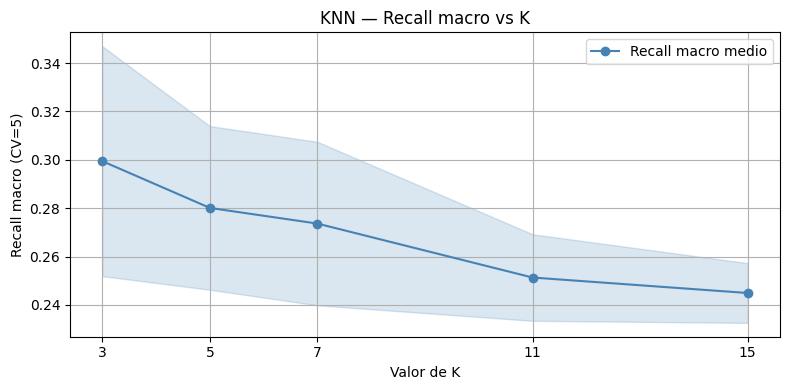

In [25]:
medias = [resultados_knn[k].mean() for k in sorted(resultados_knn)]
stds   = [resultados_knn[k].std()  for k in sorted(resultados_knn)]
ks     = sorted(resultados_knn)

plt.figure(figsize=(8, 4))
plt.plot(ks, medias, marker='o', color='steelblue', label='Recall macro medio')
plt.fill_between(ks,
                  [m - s for m, s in zip(medias, stds)],
                  [m + s for m, s in zip(medias, stds)],
                  alpha=0.2, color='steelblue')
plt.xlabel('Valor de K')
plt.ylabel('Recall macro (CV=5)')
plt.title('KNN — Recall macro vs K')
plt.xticks(ks)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
from imblearn.over_sampling import SMOTE

# Ver cuántos ejemplos tiene la clase más pequeña en train
min_samples = y_train.value_counts().min()
print("Ejemplos en la clase más pequeña:", min_samples)
print(y_train.value_counts().sort_index())

# k_neighbors debe ser menor que min_samples
smote = SMOTE(random_state=42, k_neighbors=min_samples - 1)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)

print("\nAntes de SMOTE:", y_train.value_counts().sort_index().to_dict())
print("Después de SMOTE:", pd.Series(y_train_res).value_counts().sort_index().to_dict())

Ejemplos en la clase más pequeña: 4
quality
3      24
4     173
5    1710
6    2269
7     863
8     154
9       4
Name: count, dtype: int64

Antes de SMOTE: {3: 24, 4: 173, 5: 1710, 6: 2269, 7: 863, 8: 154, 9: 4}
Después de SMOTE: {3: 2269, 4: 2269, 5: 2269, 6: 2269, 7: 2269, 8: 2269, 9: 2269}


In [29]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

modelos = {
    'KNN (mejor K, sin SMOTE)' : KNeighborsClassifier(n_neighbors=mejor_k),
    'KNN (mejor K, con SMOTE)' : KNeighborsClassifier(n_neighbors=mejor_k),
    'SVM (balanced)'           : SVC(kernel='rbf', class_weight='balanced', random_state=42),
    'SVM (con SMOTE)'          : SVC(kernel='rbf', random_state=42),
    'RandomForest (balanced)'  : RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
}

resultados = {}
for nombre, modelo in modelos.items():
    X_tr = X_train_res if 'SMOTE' in nombre else X_train_sc
    y_tr = y_train_res if 'SMOTE' in nombre else y_train

    scores = cross_val_score(modelo, X_tr, y_tr, cv=5, scoring='recall_macro', n_jobs=-1)
    resultados[nombre] = scores
    print(f"{nombre:<35} → {scores.mean():.4f} ± {scores.std():.4f}")

KNN (mejor K, sin SMOTE)            → 0.8609 ± 0.0187
KNN (mejor K, con SMOTE)            → 0.8609 ± 0.0187


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


SVM (balanced)                      → 0.3511 ± 0.0320
SVM (con SMOTE)                     → 0.7439 ± 0.0108


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


RandomForest (balanced)             → 0.3634 ± 0.0289


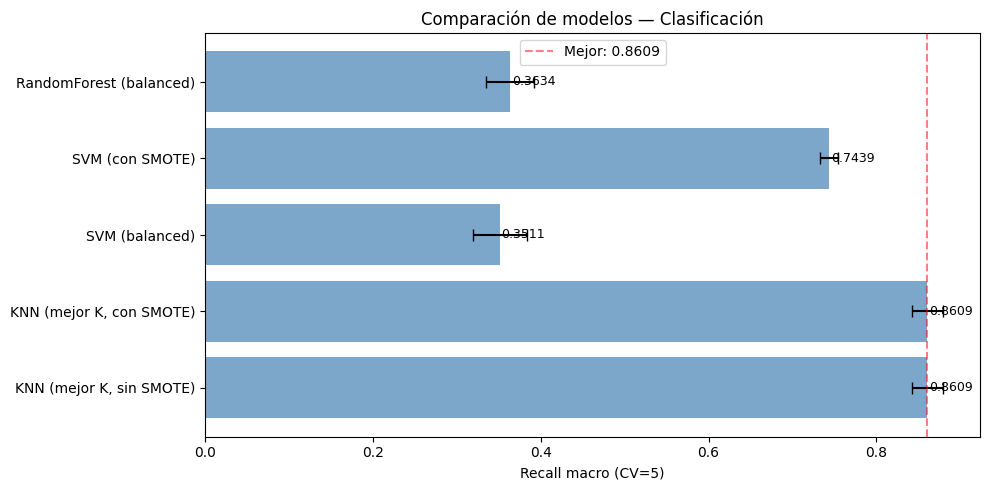


✅ Mejor modelo: KNN (mejor K, sin SMOTE) con Recall macro: 0.8609


In [ ]:
nombres = list(resultados.keys())
medias  = [resultados[n].mean() for n in nombres]
stds    = [resultados[n].std()  for n in nombres]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(nombres, medias, xerr=stds, color='steelblue', alpha=0.7, capsize=4)
ax.set_xlabel('Recall macro (CV=5)')
ax.set_title('Comparación de modelos — Clasificación')
ax.axvline(max(medias), color='red', linestyle='--', alpha=0.5, label=f'Mejor: {max(medias):.4f}')
for i, (m, s) in enumerate(zip(medias, stds)):
    ax.text(m + 0.002, i, f'{m:.4f}', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

mejor_modelo_nombre = nombres[medias.index(max(medias))]
print(f"\n Mejor modelo: {mejor_modelo_nombre} con Recall macro: {max(medias):.4f}")

In [31]:
from sklearn.model_selection import GridSearchCV

# Ajusta el modelo y param_grid según el ganador de la celda anterior
# Ejemplo con SVM balanced — cambia si ganó otro modelo

param_grid = {
    'C'     : [0.1, 1, 10, 100],
    'gamma' : ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

grid = GridSearchCV(
    SVC(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='recall_macro',
    n_jobs=-1,
    verbose=1
)

# Usa X_train_res si el ganador fue con SMOTE, X_train_sc si fue con balanced
grid.fit(X_train_sc, y_train)

print("Mejores parámetros:", grid.best_params_)
print(f"Mejor Recall macro en CV: {grid.best_score_:.4f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.

Mejores parámetros: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Mejor Recall macro en CV: 0.3959


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.11      0.37      0.17        43
           5       0.61      0.59      0.60       428
           6       0.62      0.34      0.44       567
           7       0.38      0.51      0.43       216
           8       0.15      0.46      0.22        39
           9       0.00      0.00      0.00         1

    accuracy                           0.45      1300
   macro avg       0.27      0.32      0.27      1300
weighted avg       0.54      0.45      0.47      1300


Recall macro en TEST: 0.3245


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

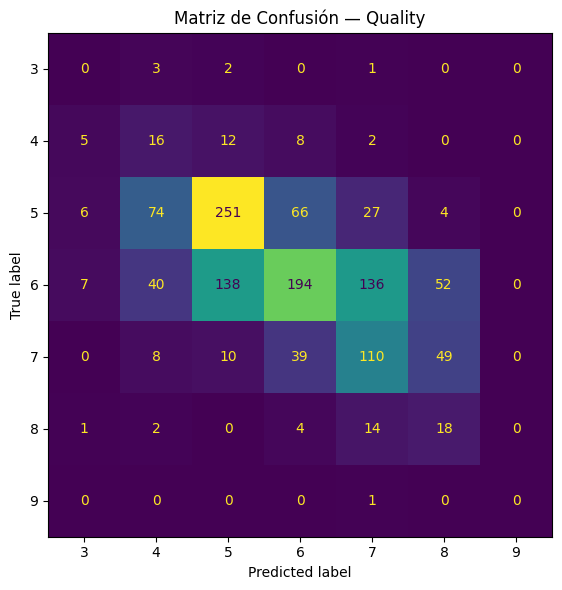

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, recall_score

modelo_final = grid.best_estimator_
y_pred = modelo_final.predict(X_test_sc)


print(classification_report(y_test, y_pred))
print(f"\nRecall macro en TEST: {recall_score(y_test, y_pred, average='macro'):.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title('Matriz de Confusión — Quality')
plt.tight_layout()
plt.show()

Tasa de error por clase real:
real
3    1.000
4    0.628
5    0.414
6    0.658
7    0.491
8    0.538
9    1.000
Name: error, dtype: float64

Distancia media del error por clase:
real
3    1.833
4    1.444
5    1.232
6    1.284
7    1.245
8    1.667
9    2.000
Name: distancia, dtype: float64


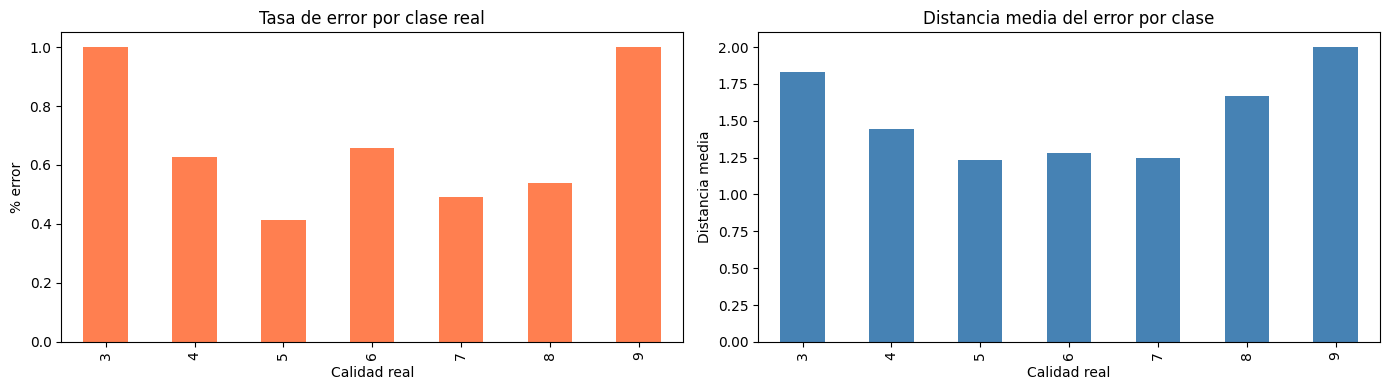

In [33]:
resultados_test = pd.DataFrame({
    'real'    : y_test.values,
    'predicho': y_pred
})
resultados_test['error']     = resultados_test['real'] != resultados_test['predicho']
resultados_test['distancia'] = abs(resultados_test['real'] - resultados_test['predicho'])

print("Tasa de error por clase real:")
print(resultados_test.groupby('real')['error'].mean().round(3))

print("\nDistancia media del error por clase:")
errores = resultados_test[resultados_test['error']]
print(errores.groupby('real')['distancia'].mean().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

resultados_test.groupby('real')['error'].mean().plot(
    kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Tasa de error por clase real')
axes[0].set_ylabel('% error')
axes[0].set_xlabel('Calidad real')

errores.groupby('real')['distancia'].mean().plot(
    kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Distancia media del error por clase')
axes[1].set_ylabel('Distancia media')
axes[1].set_xlabel('Calidad real')

plt.tight_layout()
plt.show()

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Definición de X e y para regresión
X = df.drop(columns=["alcohol"])
y = df["alcohol"]
target2 = "alcohol"

# Codificar variable categórica 'class'
X = pd.get_dummies(X, columns=['class'], drop_first=True)

# Split (sin stratify, es una variable continua)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Escalar
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape} | Test: {X_test_sc.shape}")
print(f"\nRango de alcohol en train: {y_train.min():.2f} - {y_train.max():.2f}")

Train: (5197, 12) | Test: (1300, 12)

Rango de alcohol en train: 8.00 - 14.05


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

resultados_poly = {}

for grado in [1, 2, 3]:
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=grado, include_bias=False)),
        ('reg', LinearRegression())
    ])
    scores = cross_val_score(
        pipeline, X_train_sc, y_train,
        cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1
    )
    resultados_poly[grado] = -scores  # Negamos porque sklearn devuelve negativo
    print(f"Grado {grado} → MAPE medio: {(-scores).mean():.4f} ± {scores.std():.4f}")

mejor_grado = min(resultados_poly, key=lambda g: resultados_poly[g].mean())
print(f"\nMejor grado: {mejor_grado} con MAPE: {resultados_poly[mejor_grado].mean():.4f}")

Grado 1 → MAPE medio: 0.0337 ± 0.0007
Grado 2 → MAPE medio: 0.0291 ± 0.0005
Grado 3 → MAPE medio: 0.0313 ± 0.0044

✅ Mejor grado: 2 con MAPE: 0.0291


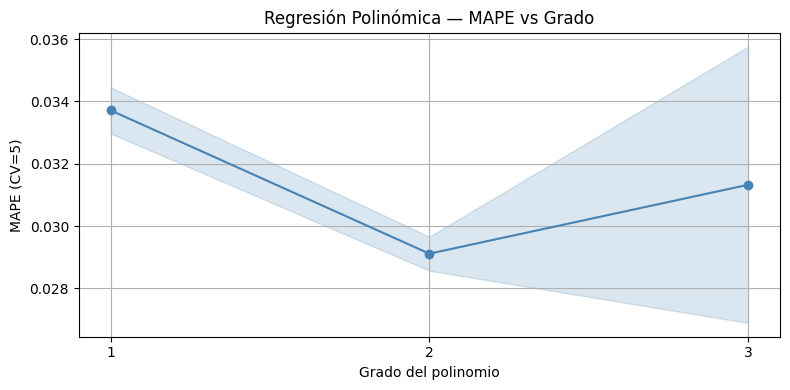

In [36]:
grados = sorted(resultados_poly)
medias = [resultados_poly[g].mean() for g in grados]
stds   = [resultados_poly[g].std()  for g in grados]

plt.figure(figsize=(8, 4))
plt.plot(grados, medias, marker='o', color='steelblue')
plt.fill_between(grados,
                  [m - s for m, s in zip(medias, stds)],
                  [m + s for m, s in zip(medias, stds)],
                  alpha=0.2, color='steelblue')
plt.xlabel('Grado del polinomio')
plt.ylabel('MAPE (CV=5)')
plt.title('Regresión Polinómica — MAPE vs Grado')
plt.xticks(grados)
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

modelos_reg = {
    'Regresión Lineal'        : LinearRegression(),
    f'Regresión Polinómica (g={mejor_grado})': Pipeline([
        ('poly', PolynomialFeatures(degree=mejor_grado, include_bias=False)),
        ('reg', LinearRegression())
    ]),
    'KNN Regressor'            : KNeighborsRegressor(n_neighbors=7),
    'SVR (rbf)'                : SVR(kernel='rbf'),
    'RandomForest Regressor'   : RandomForestRegressor(random_state=42, n_jobs=-1),
}

resultados_reg = {}
for nombre, modelo in modelos_reg.items():
    scores = cross_val_score(
        modelo, X_train_sc, y_train,
        cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1
    )
    resultados_reg[nombre] = -scores
    print(f"{nombre:<35} → MAPE: {(-scores).mean():.4f} ± {scores.std():.4f}")

Regresión Lineal                    → MAPE: 0.0337 ± 0.0007
Regresión Polinómica (g=2)          → MAPE: 0.0291 ± 0.0005
KNN Regressor                       → MAPE: 0.0425 ± 0.0013
SVR (rbf)                           → MAPE: 0.0275 ± 0.0009
RandomForest Regressor              → MAPE: 0.0268 ± 0.0011


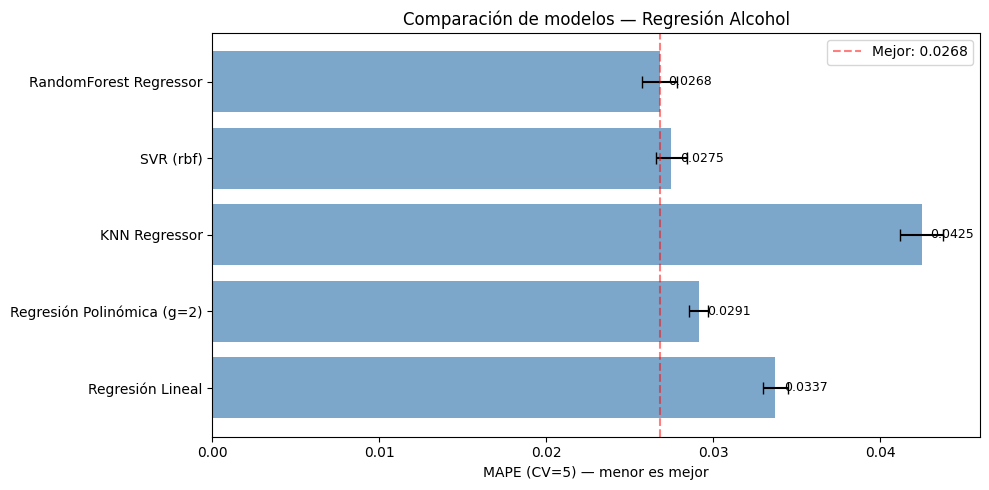


 Mejor modelo: RandomForest Regressor con MAPE: 0.0268


In [38]:
nombres = list(resultados_reg.keys())
medias  = [resultados_reg[n].mean() for n in nombres]
stds    = [resultados_reg[n].std()  for n in nombres]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(nombres, medias, xerr=stds, color='steelblue', alpha=0.7, capsize=4)
ax.set_xlabel('MAPE (CV=5) — menor es mejor')
ax.set_title('Comparación de modelos — Regresión Alcohol')
ax.axvline(min(medias), color='red', linestyle='--', alpha=0.5, label=f'Mejor: {min(medias):.4f}')
for i, (m, s) in enumerate(zip(medias, stds)):
    ax.text(m + 0.0005, i, f'{m:.4f}', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

mejor_modelo_reg_nombre = nombres[medias.index(min(medias))]
print(f"\n Mejor modelo: {mejor_modelo_reg_nombre} con MAPE: {min(medias):.4f}")

In [39]:
from sklearn.model_selection import GridSearchCV

# Ejemplo con SVR — ajusta según el modelo ganador de la celda anterior

param_grid = {
    'C'      : [0.1, 1, 10, 100],
    'gamma'  : ['scale', 'auto', 0.01, 0.1],
    'epsilon': [0.01, 0.1, 0.5]
}

grid_reg = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1,
    verbose=1
)
grid_reg.fit(X_train_sc, y_train)

print("Mejores parámetros:", grid_reg.best_params_)
print(f"Mejor MAPE en CV: {-grid_reg.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Mejores parámetros: {'C': 10, 'epsilon': 0.01, 'gamma': 0.1}
Mejor MAPE en CV: 0.0257


MAPE en TEST: 0.0257 (2.57%)
MAE  en TEST: 0.2706
R²   en TEST: 0.8862


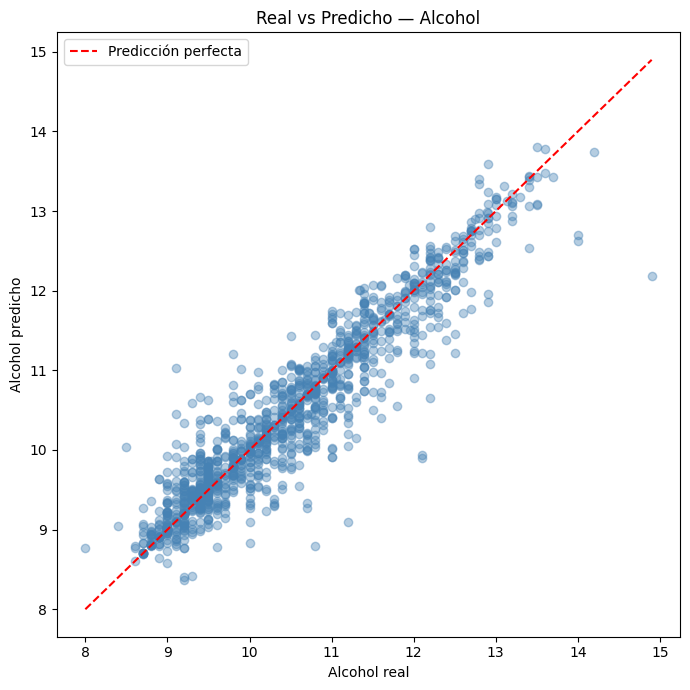

In [40]:
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score

modelo_reg_final = grid_reg.best_estimator_
y_pred_reg = modelo_reg_final.predict(X_test_sc)

mape = mean_absolute_percentage_error(y_test, y_pred_reg)
mae  = mean_absolute_error(y_test, y_pred_reg)
r2   = r2_score(y_test, y_pred_reg)

print(f"MAPE en TEST: {mape:.4f} ({mape*100:.2f}%)")
print(f"MAE  en TEST: {mae:.4f}")
print(f"R²   en TEST: {r2:.4f}")

# Gráfico real vs predicho
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_reg, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Predicción perfecta')
plt.xlabel('Alcohol real')
plt.ylabel('Alcohol predicho')
plt.title('Real vs Predicho — Alcohol')
plt.legend()
plt.tight_layout()
plt.show()

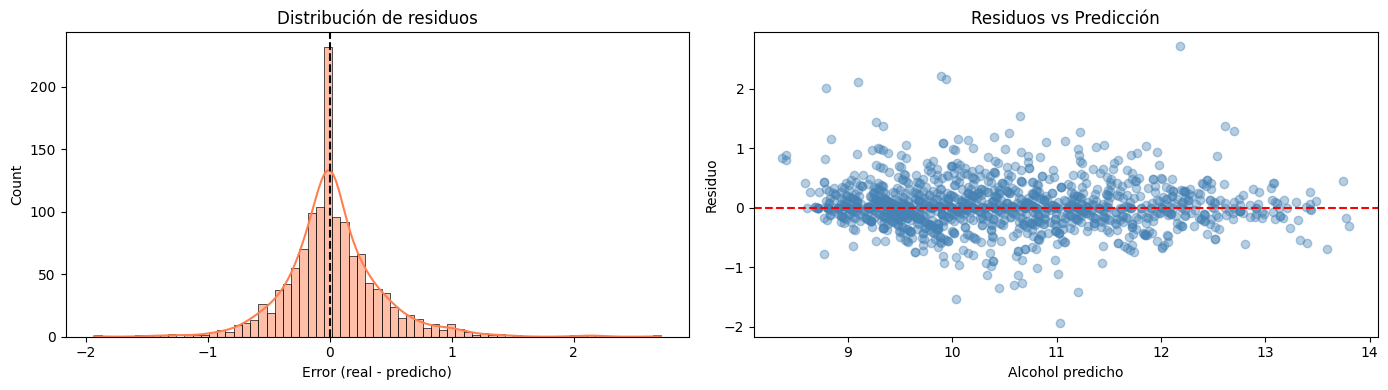

Estadísticas de residuos:
count    1300.000
mean        0.030
std         0.400
min        -1.936
25%        -0.170
50%        -0.002
75%         0.202
max         2.715
dtype: float64


In [41]:
residuos = y_test.values - y_pred_reg

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribución de residuos
sns.histplot(residuos, kde=True, ax=axes[0], color='coral')
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set_title('Distribución de residuos')
axes[0].set_xlabel('Error (real - predicho)')

# Residuos vs valor predicho (heterocedasticidad)
axes[1].scatter(y_pred_reg, residuos, alpha=0.4, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuos vs Predicción')
axes[1].set_xlabel('Alcohol predicho')
axes[1].set_ylabel('Residuo')

plt.tight_layout()
plt.show()

print("Estadísticas de residuos:")
print(pd.Series(residuos).describe().round(3))